# Bài giải: Hiểu dữ liệu (Data Understanding) — Bài tập 2, 3, 4

Notebook này tính toán và vẽ lại chính xác các thống kê mô tả, boxplot, scatter plot,
ma trận hiệp phương sai và kiểm định chi-square cho ba bài tập trong slide "Data Understanding".

**Cách chạy:**
```bash
pip install numpy pandas matplotlib scipy
jupyter notebook
```
Chạy tuần tự từng cell (Shift+Enter) — mọi số liệu và hình vẽ trong notebook đều được
tính trực tiếp từ dữ liệu gốc, không hard-code kết quả, nên bạn có thể sửa dữ liệu và
chạy lại để tự kiểm tra hoặc dùng cho bộ dữ liệu khác.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


---
## Bài 2 — Tuổi và tỉ lệ mỡ cơ thể (18 người)

Một bệnh viện đo tuổi (`age`) và tỉ lệ mỡ cơ thể (`%fat`) của 18 người trưởng thành.

**Yêu cầu:** (a) mean, median, variance, std dev của age và %fat · (b) boxplot cho age và %fat ·
(c) scatter plot giữa hai biến · (d) hệ số tương quan Pearson và Spearman.

In [2]:
age = [23,23,27,27,39,41,47,49,50,52,54,54,56,57,58,58,60,61]
fat = [9.5,26.5,7.8,17.8,31.4,25.9,27.4,27.2,31.2,34.6,42.5,28.8,33.4,30.2,34.1,32.9,41.2,35.7]

df2 = pd.DataFrame({"age": age, "%fat": fat})
df2


,age,%fat
0,23,9.5
1,23,26.5
2,27,7.8
3,27,17.8
4,39,31.4
5,41,25.9
6,47,27.4
7,49,27.2
8,50,31.2
9,52,34.6


In [3]:
# (a) Mean, median, variance (population, ddof=0), std dev
summary2 = pd.DataFrame({
    "mean":   df2.mean(),
    "median": df2.median(),
    "variance (population)": df2.var(ddof=0),
    "std dev (population)":  df2.std(ddof=0),
})
summary2


,mean,median,variance (population),std dev (population)
age,46.444444,51.0,165.024691,12.846194
%fat,28.783333,30.7,80.885833,8.993655


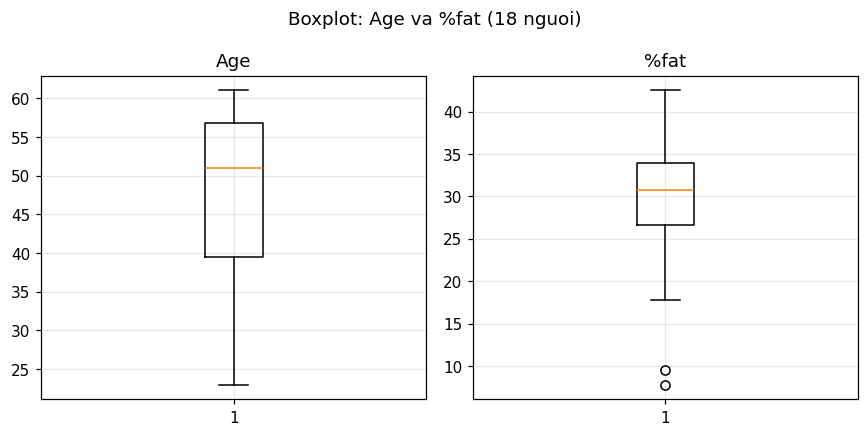

In [4]:
# (b) Boxplot cho age va %fat
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].boxplot(df2["age"], vert=True)
axes[0].set_title("Age")
axes[1].boxplot(df2["%fat"], vert=True)
axes[1].set_title("%fat")
fig.suptitle("Boxplot: Age va %fat (18 nguoi)")
plt.tight_layout()
plt.show()


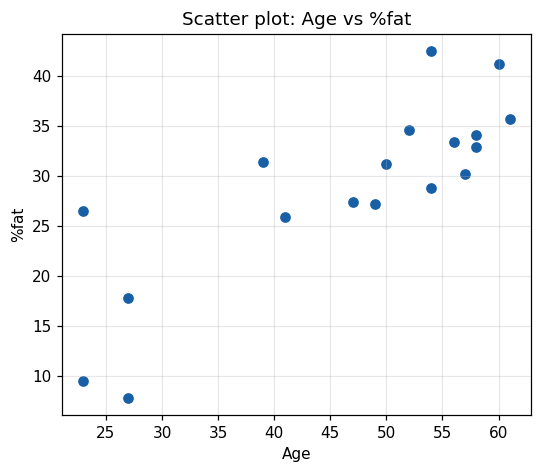

In [5]:
# (c) Scatter plot age vs %fat
plt.figure(figsize=(5.5, 4.5))
plt.scatter(df2["age"], df2["%fat"], color="#185fa5")
plt.xlabel("Age")
plt.ylabel("%fat")
plt.title("Scatter plot: Age vs %fat")
plt.show()


In [6]:
# (d) He so tuong quan Pearson va Spearman
r, p_pearson = stats.pearsonr(df2["age"], df2["%fat"])
rho, p_spearman = stats.spearmanr(df2["age"], df2["%fat"])
print(f"Pearson  r   = {r:.4f}  (p-value = {p_pearson:.4g})")
print(f"Spearman rho = {rho:.4f}  (p-value = {p_spearman:.4g})")


Pearson  r   = 0.8176  (p-value = 3.413e-05)
Spearman rho = 0.8066  (p-value = 5.254e-05)


---
## Bài 3 — Ronaldo tại Champions League (2003/04 → 2021/22, 19 mùa)

Dữ liệu D gồm số trận ra sân (`Apps`), số bàn thắng (`Goals`), số kiến tạo (`Assists`) của
Cristiano Ronaldo tại Champions League qua từng mùa giải.

**Yêu cầu:** (a) mean, median, mode, variance, std dev của 3 thuộc tính · (b) Q1, Q3 ·
(c) boxplot · (d) scatter plot từng cặp thuộc tính · (e) ma trận hiệp phương sai.

In [7]:
clubs   = ["Man United"]*6 + ["Real Madrid"]*9 + ["Juventus"]*3 + ["Man United"]
seasons = ["03/04","04/05","05/06","06/07","07/08","08/09",
           "09/10","10/11","11/12","12/13","13/14","14/15","15/16","16/17","17/18",
           "18/19","19/20","20/21","21/22"]
apps    = [5,7,6,11,11,12, 6,12,10,12,11,12,12,13,13, 9,8,6, 7]
goals   = [0,0,0,3,8,4,   7,6,10,12,17,10,16,12,15,  6,4,4,  6]
assists = [1,2,0,5,1,3,   1,4,3,1,5,4,4,6,3,          2,1,2,  0]

df3 = pd.DataFrame({"Club": clubs, "Season": seasons,
                     "Apps": apps, "Goals": goals, "Assists": assists})
df3


,Club,Season,Apps,Goals,Assists
0,Man United,03/04,5,0,1
1,Man United,04/05,7,0,2
2,Man United,05/06,6,0,0
3,Man United,06/07,11,3,5
4,Man United,07/08,11,8,1
5,Man United,08/09,12,4,3
6,Real Madrid,09/10,6,7,1
7,Real Madrid,10/11,12,6,4
8,Real Madrid,11/12,10,10,3
9,Real Madrid,12/13,12,12,1


In [8]:
# (a) Mean, median, mode, variance, std dev
num_cols = ["Apps", "Goals", "Assists"]

summary3 = pd.DataFrame({
    "mean":   df3[num_cols].mean(),
    "median": df3[num_cols].median(),
    "mode":   df3[num_cols].apply(lambda c: list(c.mode())),
    "variance (population)": df3[num_cols].var(ddof=0),
    "std dev (population)":  df3[num_cols].std(ddof=0),
})
summary3


,mean,median,mode,variance (population),std dev (population)
Apps,9.631579,11.0,[12],7.074792,2.659848
Goals,7.368421,6.0,"[0, 4, 6]",26.548476,5.152521
Assists,2.526316,2.0,[1],2.986150,1.728048


In [9]:
# (b) Q1, Q3, IQR (phuong phap median-of-halves, giong cach tinh tay trong bai giai)
def quartiles_median_of_halves(x):
    xs = sorted(x)
    n = len(xs)
    mid = n // 2
    lower = xs[:mid]
    upper = xs[mid+1:] if n % 2 == 1 else xs[mid:]
    def med(l):
        m = len(l)
        return l[m//2] if m % 2 == 1 else (l[m//2 - 1] + l[m//2]) / 2
    return med(lower), med(upper)

for col in num_cols:
    q1, q3 = quartiles_median_of_halves(df3[col])
    print(f"{col:8s}  Q1 = {q1:5.2f}   Q3 = {q3:5.2f}   IQR = {q3-q1:5.2f}")


Apps      Q1 =  7.00   Q3 = 12.00   IQR =  5.00
Goals     Q1 =  4.00   Q3 = 12.00   IQR =  8.00
Assists   Q1 =  1.00   Q3 =  4.00   IQR =  3.00


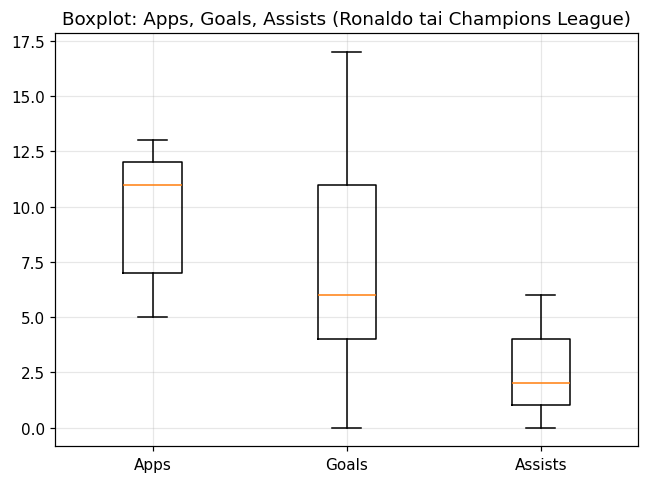

In [10]:
# (c) Boxplot cho ca ba thuoc tinh
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.boxplot([df3["Apps"], df3["Goals"], df3["Assists"]],
           tick_labels=["Apps", "Goals", "Assists"])
ax.set_title("Boxplot: Apps, Goals, Assists (Ronaldo tai Champions League)")
plt.tight_layout()
plt.show()


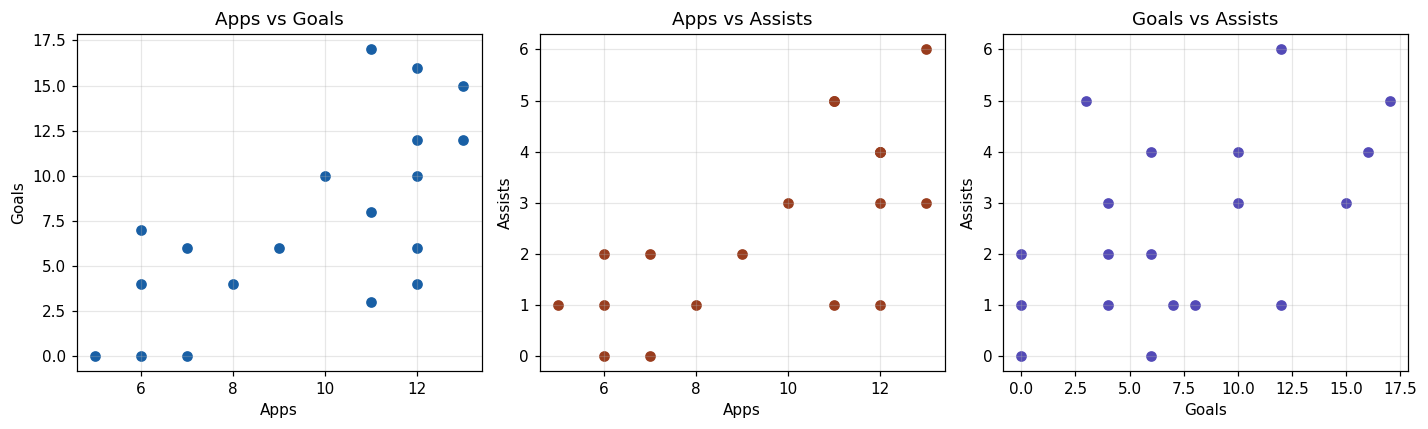

In [11]:
# (d) Scatter plot cho tung cap thuoc tinh
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pairs = [("Apps", "Goals"), ("Apps", "Assists"), ("Goals", "Assists")]
colors = ["#185fa5", "#993c1d", "#534ab7"]
for ax, (x, y), c in zip(axes, pairs, colors):
    ax.scatter(df3[x], df3[y], color=c)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")
plt.tight_layout()
plt.show()


In [12]:
# (e) Ma tran hiep phuong sai (population, ddof=0)
cov_matrix = df3[num_cols].cov(ddof=0)
cov_matrix


,Apps,Goals,Assists
Apps,7.074792,9.504155,3.193906
Goals,9.504155,26.548476,4.437673
Assists,3.193906,4.437673,2.986150


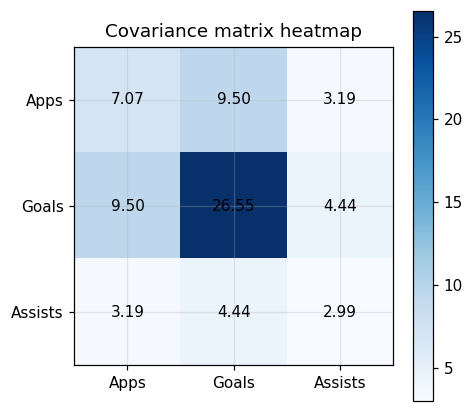

In [13]:
# Truc quan hoa ma tran hiep phuong sai bang heatmap
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cov_matrix, cmap="Blues")
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{cov_matrix.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Covariance matrix heatmap")
fig.colorbar(im)
plt.tight_layout()
plt.show()


---
## Bài 4 — Chuyên ngành và sở thích chơi game (800 sinh viên)

Bảng tần suất chéo (contingency table) giữa chuyên ngành (Toán / Lịch sử / Khoa học máy tính)
và việc thích chơi game máy tính hay không.

**Yêu cầu:** (a) tần suất kỳ vọng của mỗi ô · (b) kiểm định chi-square để xác nhận
tương quan giữa hai biến.

In [14]:
observed = pd.DataFrame(
    {"Thich": [130, 35, 280], "Khong_thich": [100, 165, 90]},
    index=["Toan", "Lich_su", "Khoa_hoc_may_tinh"]
)
observed


,Thich,Khong_thich
Toan,130,100
Lich_su,35,165
Khoa_hoc_may_tinh,280,90


In [15]:
chi2, p_value, dof, expected = stats.chi2_contingency(observed, correction=False)

expected_df = pd.DataFrame(expected, index=observed.index, columns=observed.columns)
print("Tan suat ky vong (expected frequencies):")
display(expected_df.round(2))

print(f"\nchi2 = {chi2:.4f}")
print(f"degrees of freedom = {dof}")
print(f"p-value = {p_value:.6g}")

alpha = 0.001
crit = stats.chi2.ppf(1 - alpha, dof)
print(f"\nNguong bac bo tai alpha={alpha}, dof={dof}: {crit:.3f}")
print("=> Bac bo H0 (hai bien doc lap)" if chi2 > crit else "=> Khong du co so bac bo H0")


Tan suat ky vong (expected frequencies):


,Thich,Khong_thich
Toan,127.94,102.06
Lich_su,111.25,88.75
Khoa_hoc_may_tinh,205.81,164.19



chi2 = 178.1098
degrees of freedom = 2
p-value = 2.10836e-39

Nguong bac bo tai alpha=0.001, dof=2: 13.816
=> Bac bo H0 (hai bien doc lap)


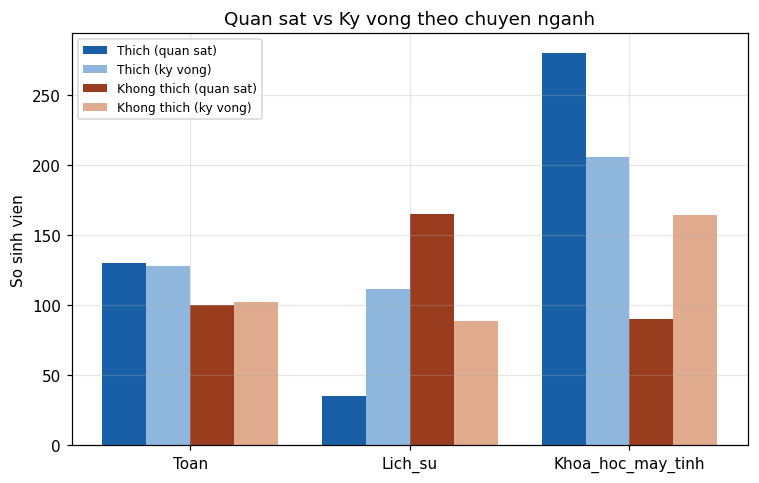

In [16]:
# Truc quan hoa: quan sat vs ky vong theo tung nhom
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(observed.index))
width = 0.2
ax.bar(x - 1.5*width, observed["Thich"], width, label="Thich (quan sat)", color="#185fa5")
ax.bar(x - 0.5*width, expected_df["Thich"], width, label="Thich (ky vong)", color="#8fb7dd")
ax.bar(x + 0.5*width, observed["Khong_thich"], width, label="Khong thich (quan sat)", color="#993c1d")
ax.bar(x + 1.5*width, expected_df["Khong_thich"], width, label="Khong thich (ky vong)", color="#e0ab8f")
ax.set_xticks(x)
ax.set_xticklabels(observed.index)
ax.set_ylabel("So sinh vien")
ax.set_title("Quan sat vs Ky vong theo chuyen nganh")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## Ghi chú

- Toàn bộ số liệu và công thức trong notebook này đúng với lời giải chi tiết đã trình bày
  trong bài giảng "Hiểu dữ liệu" (Data Understanding).
- `ddof=0` (chia cho n) được dùng nhất quán cho variance/std/covariance để khớp với công thức
  trong slide gốc; đổi sang `ddof=1` nếu bạn muốn ước lượng không chệch (chia cho n−1).
- Bạn có thể thay `age/fat`, `apps/goals/assists`, hoặc bảng `observed` bằng dữ liệu khác và
  chạy lại toàn bộ notebook để tự động có đầy đủ số liệu + hình vẽ tương ứng.